# Wheat spike detection & counting with YOLOXP (inference on released model + sample)

**Paper:** *"RGB imaging and computer vision-based approaches for identifying spike number loci for wheat."*
Plant Phenomics 7(2): 100051 (2025). DOI: [10.1016/j.plaphe.2025.100051](https://doi.org/10.1016/j.plaphe.2025.100051) (open access, PMC12710032)

**Author code:** [`lileimax/YOLOXP-wheat-spike-identification`](https://github.com/lileimax/YOLOXP-wheat-spike-identification) pinned at commit `ba5e8f30699f3ec87c83b4ae30700925a0f391e8`

**Scope of this notebook (inference-only):** load the authors' released `YOLOXP.h5` and `YOLOX.h5` checkpoints with their pinned Keras code, run spike detection on **three released canopy images** (one from each of the `CD`, `DD`, `XA` image subsets of the released CD&DD&XX set), and **compare predicted spike counts with the released VOC XML annotations** (ground truth). This is a minimal single-image-scale demonstration of the paper's central result (YOLOX-P vs YOLOX and model-count vs manual-count agreement); it is **not** a reproduction of the paper's dataset-level mAP / QTL results.

* **推論のみのデモです。** 論文の学習済みモデル `YOLOXP.h5` と `YOLOX.h5` を著者公開コードで読み込み、公開データセットから各サブセット（CD / DD / XA）1 枚ずつ、計 3 枚の群落画像で穂検出を実行し、アノテーション（正解）の穂数と比較します。
* データセット全体の mAP 評価や QTL 解析（遺伝データが必要）は含みません。

**License note / ライセンスに関する注意:** the author repository has an **empty LICENSE file** (no explicit license). This notebook runs the authors' code transiently for educational reproduction with full attribution; consult the authors before any redistribution.

**Runtime:** select **Runtime → Change runtime type → T4 GPU** (recommended) or plain CPU; the same cells run on both. Execute **Runtime → Run all**.
Estimated (not measured) end-to-end time: a few minutes on T4, ~5–15 min on CPU. Downloads ≈ 130 MB (two 36 MB checkpoints, a 9.7 MB font, 3 images + annotations).

## 1. Environment setup

The authors' code is TF 2.2-era Keras 2. Colab ships Keras 3, so we install the official `tf-keras` (Keras 2 compatibility) package and set `TF_USE_LEGACY_KERAS=1` **before the first `import tensorflow`** — this keeps the authors' `Model`/`Lambda`/weight-loading semantics exactly as written.

**Expected result:** `tf-keras` installs; no restart is needed as long as TensorFlow was not imported earlier in this kernel.

著者コードは Keras 2 (TF 2.2 時代) で書かれています。Colab の Keras 3 ではなく、公式の互換パッケージ `tf-keras` を Keras 2 として使うよう環境変数を設定してから TensorFlow を初めて import します。

In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"  # must be set BEFORE the first `import tensorflow`

%pip install -q tf-keras gdown
print("TF_USE_LEGACY_KERAS =", os.environ["TF_USE_LEGACY_KERAS"])

TF_USE_LEGACY_KERAS = 1


Now import TensorFlow and report the actual runtime hardware (CPU, or GPU if you selected one).

TensorFlow を読み込み、実際に割り当てられたランタイム（CPU / GPU）とバージョンを表示します。

In [ ]:
import sys, tensorflow as tf, tf_keras
print("Python        :", sys.version.split()[0])
print("TensorFlow    :", tf.__version__)
print("tf_keras      :", tf_keras.__version__, "(legacy Keras 2 API used by the authors' code)")
print("tf.keras module:", tf.keras.__name__)
gpus = tf.config.list_physical_devices("GPU")
print("Physical GPUs :", gpus)
DEVICE = "GPU" if gpus else "CPU"
print("DEVICE =", DEVICE)

Python        : 3.13.15
TensorFlow    : 2.21.0
tf_keras      : 2.21.0 (legacy Keras 2 API used by the authors' code)
tf.keras module: tf_keras.api._v2.keras


Physical GPUs : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
DEVICE = GPU


## 2. Download the pinned author code (commit `ba5e8f3`)

We fetch only the files needed for inference from the authors' repository at the exact pinned commit, and assert each file's expected size (from the pinned git tree) so any upstream change fails loudly.

著者のリポジトリから、推論に必要なファイルだけを固定コミットからダウンロードし、サイズを検証します。

In [ ]:
import urllib.request, os

COMMIT = "ba5e8f30699f3ec87c83b4ae30700925a0f391e8"
RAW = f"https://raw.githubusercontent.com/lileimax/YOLOXP-wheat-spike-identification/{COMMIT}"
REPO_DIR = "/content/YOLOXP"

# path -> expected size in bytes (verified against the pinned commit's git tree)
CODE_FILES = {
    "yolo.py": 9608,                  # YOLO class: model build, load_weights, detect
    "nets/yolo.py": 4594,             # yolo_body with CBAM in the neck (YOLOX-P)
    "nets/CSPdarknet.py": 9219,       # CSPdarknet + CBAM attention blocks
    "nets/yolo_training.py": 15716,   # imported by nets/yolo.py
    "utils/utils.py": 7776,           # cvtColor / resize_image / preprocess_input
    "utils/utils_bbox.py": 5396,      # DecodeBox: decoding + NMS
    "model_data/voc_classes.txt": 6,  # class list ("wheat")
}

def fetch(url, dst, timeout=120):
    req = urllib.request.Request(url, headers={"User-Agent": "colab-reproduction/1.0"})
    with urllib.request.urlopen(req, timeout=timeout) as r, open(dst, "wb") as f:
        f.write(r.read())

for rel, size in CODE_FILES.items():
    dst = os.path.join(REPO_DIR, rel)
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    fetch(f"{RAW}/{rel}", dst)
    got = os.path.getsize(dst)
    assert got == size, f"{rel}: expected {size} bytes, got {got}"
    print(f"{rel:32s} {got:>9,d} bytes  OK")
print("Author code pinned at", COMMIT)

yolo.py                              9,608 bytes  OK
nets/yolo.py                         4,594 bytes  OK


nets/CSPdarknet.py                   9,219 bytes  OK
nets/yolo_training.py               15,716 bytes  OK


utils/utils.py                       7,776 bytes  OK
utils/utils_bbox.py                  5,396 bytes  OK


model_data/voc_classes.txt               6 bytes  OK
Author code pinned at ba5e8f30699f3ec87c83b4ae30700925a0f391e8


## 3. Download the released checkpoints and font

`logs/best_epoch_weights of YOLOXP.h5` (the paper's improved YOLOX-P: CBAM in the neck, 960×960 input) and `logs/best_epoch_weights of YOLOX.h5` (the YOLOX baseline, 640×640 — the paper raised the input resolution to 960 only for YOLOX-P) plus `model_data/simhei.ttf`, which the authors' drawing code uses. These are plain git blobs (not Git LFS), so pinned raw URLs serve the real bytes. We verify each file by **recomputing its git blob SHA-1** against the SHA recorded in the pinned commit's tree.

**Expected result:** two ~36 MB H5 weight files and one ~9.8 MB font, all matching their recorded blob SHAs.

学習済みチェックポイント 2 種（YOLOXP と YOLOX ベースライン）と描画用フォントをダウンロードし、git blob SHA-1 を再計算して検証します。

In [ ]:
import hashlib

# path -> (expected size, git blob SHA-1 at the pinned commit)
BINARY_FILES = {
    "logs/best_epoch_weights of YOLOXP.h5": (36575536, "000cb5a956313ba3fd653acdbbbdbde93eaf28e9"),
    "logs/best_epoch_weights of YOLOX.h5":  (36453152, "4dd4ff5d2bfad26d7eba2d6d546b86a1b7e752fc"),
    "model_data/simhei.ttf":                (9753388,  "5bd4687e7212775e23bea569f08fdd1cd7395dc3"),
}

def git_blob_sha(path):
    h = hashlib.sha1()
    h.update(f"blob {os.path.getsize(path)}\0".encode())
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

for rel, (size, sha) in BINARY_FILES.items():
    dst = os.path.join(REPO_DIR, rel)
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    fetch(f"{RAW}/{urllib.request.quote(rel)}", dst)
    got = os.path.getsize(dst)
    assert got == size, f"{rel}: expected {size} bytes, got {got}"
    got_sha = git_blob_sha(dst)
    assert got_sha == sha, f"{rel}: blob sha {got_sha} != {sha}"
    print(f"{rel:45s} {got:>10,d} bytes  blob SHA OK")

logs/best_epoch_weights of YOLOXP.h5          36,575,536 bytes  blob SHA OK


logs/best_epoch_weights of YOLOX.h5           36,453,152 bytes  blob SHA OK


model_data/simhei.ttf                          9,753,388 bytes  blob SHA OK


## 4. Download three released sample images + annotations (Google Drive)

The paper's Drive link hosts the VOC2007-format **CD&DD&XX** set (1920 image/annotation pairs; 594 `CD*`, 610 `DD*`, 716 `XA*`). We download exactly **one pair per subset** (`CD0100`, `DD0100`, `XA0100`) plus the `ImageSets/Main` split lists, and verify each image opens and each annotation parses. Bytes stay inside this Colab VM (`/content/data`).

**Expected result:** 3 JPGs + 3 XMLs + 3 split lists, and each sample's train/val/test membership.

論文の Drive 公開データ（VOC2007 形式）から、各サブセット 1 枚ずつ・計 3 枚の画像と対応するアノテーション XML、分割リストのみをダウンロードして検証します。

In [ ]:
import gdown, xml.etree.ElementTree as ET
from PIL import Image

DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

# file IDs read from the public Drive folder listing (folder 1urCDUdyrq14FuwG2I3YwCZraUGEEl_8X)
SAMPLES = {  # name: (JPG id, XML id)
    "CD0100": ("1gKFpcWgnl_E2HR5EK62mA9uXY_8vvZv-", "1jXYinu8Bc33DXWb6kpQgBh1n-dufl1eH"),
    "DD0100": ("1DivDRlxDSOV0qNBJFjUPTknDu4md55p_", "1roDL4ZR43TI8RSixR7y5kP2DKJxdSYii"),
    "XA0100": ("1gNP2lwTmKg_r6No_YrlxcdtoO3Bm6rHv", "1OavEhq-IXGAFS3xP86-jP2A4yOYFchAm"),
}
SPLIT_IDS = {  # ImageSets/Main split lists
    "train": "1T4GjlVaN2qFqc0QdsZ9gVbyBiS14JNkE",
    "val":   "1oUquIKtiRpgTx1Bo5dn11KYAI8enT68K",
    "test":  "17rBnlIhCV4LJ7Uh3LjLFBHaRE0d_3eiz",
}

for name, (img_id, xml_id) in SAMPLES.items():
    gdown.download(id=img_id, output=f"{DATA_DIR}/{name}.JPG", quiet=True)
    gdown.download(id=xml_id, output=f"{DATA_DIR}/{name}.xml", quiet=True)
    im = Image.open(f"{DATA_DIR}/{name}.JPG"); im.verify()
    root = ET.parse(f"{DATA_DIR}/{name}.xml").getroot()
    print(f"{name}: {os.path.getsize(f'{DATA_DIR}/{name}.JPG'):,d} bytes, "
          f"{Image.open(f'{DATA_DIR}/{name}.JPG').size}, "
          f"{len(root.findall('object'))} annotated objects")

splits = {}
for split, fid in SPLIT_IDS.items():
    p = f"{DATA_DIR}/ImageSets_{split}.txt"
    gdown.download(id=fid, output=p, quiet=True)
    splits[split] = set(open(p).read().split())
for name in SAMPLES:
    where = [s for s, ids in splits.items() if name in ids]
    print(f"{name} is in ImageSets split(s): {where or ['(none of train/val/test lists)']}")

CD0100: 5,170,149 bytes, (2450, 2247), 94 annotated objects


DD0100: 2,212,276 bytes, (2504, 2247), 114 annotated objects


XA0100: 2,046,567 bytes, (1963, 2010), 123 annotated objects


CD0100 is in ImageSets split(s): ['val']
DD0100 is in ImageSets split(s): ['train']
XA0100 is in ImageSets split(s): ['train']


## 5. Input preview — released images with their ground-truth (annotated) spike boxes

Before any model call, we draw the **released VOC XML annotations** (green) on each downloaded image. These boxes were produced by the authors with LabelImg (paper Section 2.3) and are the ground truth our counts are compared against. Red numbers are the per-image annotated spike count.

**Expected result:** three canopy photos with dense green spike bounding boxes.

モデル実行の前に、ダウンロードした画像に公開アノテーション（正解の穂 bounding box、緑）を重ねて表示します。各画像の左上の数字はアノテーションされた穂数です。

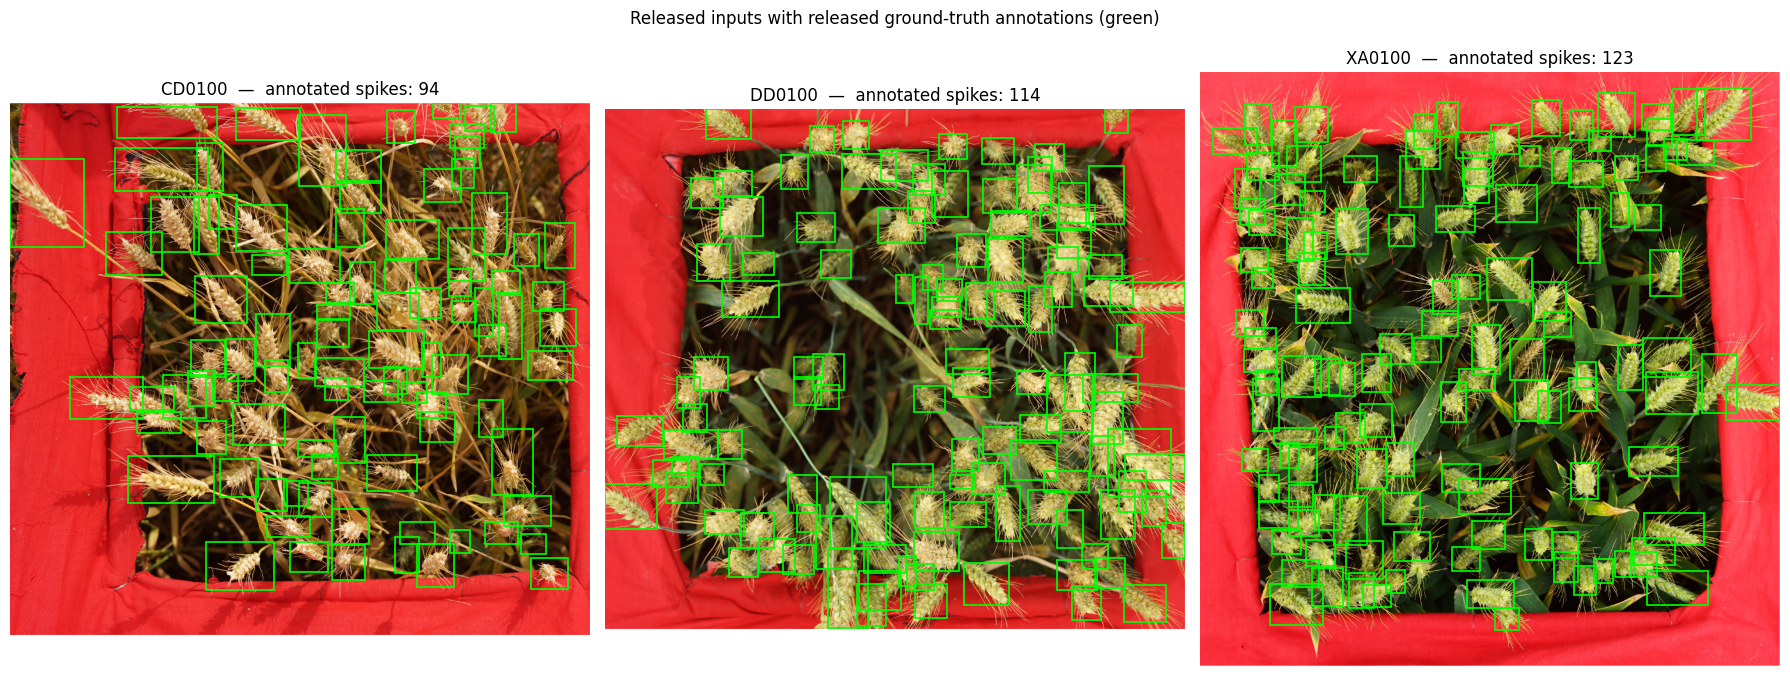

Saved /content/preview_gt.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def gt_objects(xml_path):
    root = ET.parse(xml_path).getroot()
    out = []
    for obj in root.findall("object"):
        bb = obj.find("bndbox")
        out.append((int(bb.findtext("xmin")), int(bb.findtext("ymin")),
                    int(bb.findtext("xmax")), int(bb.findtext("ymax"))))
    return out

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, name in zip(axes, SAMPLES):
    im = Image.open(f"{DATA_DIR}/{name}.JPG").convert("RGB")
    boxes = gt_objects(f"{DATA_DIR}/{name}.xml")
    ax.imshow(im)
    for (xmin, ymin, xmax, ymax) in boxes:
        ax.add_patch(patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                       linewidth=1.2, edgecolor="lime", facecolor="none"))
    ax.set_title(f"{name}  —  annotated spikes: {len(boxes)}")
    ax.axis("off")
fig.suptitle("Released inputs with released ground-truth annotations (green)", y=0.99)
plt.tight_layout()
plt.savefig("/content/preview_gt.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved /content/preview_gt.png")

## 6. Build the authors' model and load the released weights

We import the authors' `YOLO` class from the pinned download, which builds `yolo_body` (CSPdarknet-s, exactly as in `nets/`) and calls `load_weights` on the released H5 (a Keras *weights-only* file saved by the authors' training script, `save_weights_only=True` in `train.py`). We instantiate **YOLOXP at 960×960** (authors' default in `yolo.py`, with the CBAM attention blocks that define YOLOX-P) and the **YOLOX baseline at 640×640** (the paper raised the input resolution to 960 only for YOLOX-P; the Keras-community YOLOX default the authors forked is 640).

**One documented adaptation:** the released `nets/` code contains only the CBAM-modified YOLOX-P body. The released **YOLOX baseline checkpoint stores 157 layers, i.e. without the two CBAM blocks** (the YOLOX-P body has 163 and loads into it unchanged — verified in the first execution of this notebook). To load the baseline faithfully we build it from the same pinned `yolo_body` with the CBAM blocks neutralized *for that instantiation only* (this is how the authors trained the baseline: CBAM is YOLOX-P's contribution). Decoding uses the authors' `DecodeBox` (confidence 0.2, NMS IoU 0.3, letterbox) — all authors' defaults.

**Expected result:** both checkpoints load with no missing/unexpected layers and the configuration table prints.

著者の `YOLO` クラスを使い、公開重みを読み込みます。YOLOXP は 960×960、YOLOX ベースラインは 640×640（論文は YOLOX-P のみ解像度を 960 に引き上げ）です。公開コードには CBAM 付きの本体しかないため、ベースライン読み込み時のみ CBAM を無効化して構築します（ベースラインのチェックポイントは CBAM を含まない 157 層であることを実行時に確認済み）。

In [ ]:
import sys, time
os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)

from yolo import YOLO  # authors' class, pinned commit

t0 = time.time()
yoloxp = YOLO(model_path="logs/best_epoch_weights of YOLOXP.h5", input_shape=[960, 960])
print(f"YOLOXP ready in {time.time()-t0:.1f}s")

# YOLOX baseline: same pinned yolo_body, but with the CBAM blocks neutralized.
import nets.yolo
nets.yolo.cbam_block = lambda x, ratio=8, name="": x  # baseline has no attention blocks
t0 = time.time()
yolox = YOLO(model_path="logs/best_epoch_weights of YOLOX.h5", input_shape=[640, 640])
print(f"YOLOX baseline ready in {time.time()-t0:.1f}s")

logs/best_epoch_weights of YOLOXP.h5 model, and classes loaded.
Configurations:
----------------------------------------------------------------------
|                     keys |                                   values|
----------------------------------------------------------------------
|               model_path |               logs/best_epoch_weights.h5|
|             classes_path |               model_data/voc_classes.txt|
|              input_shape |                               [960, 960]|
|                      phi |                                        s|
|               confidence |                                      0.2|
|                  nms_iou |                                      0.3|
|                max_boxes |                                      200|
|          letterbox_image |                                     True|
----------------------------------------------------------------------
YOLOXP ready in 3.5s


logs/best_epoch_weights of YOLOX.h5 model, and classes loaded.
Configurations:
----------------------------------------------------------------------
|                     keys |                                   values|
----------------------------------------------------------------------
|               model_path |               logs/best_epoch_weights.h5|
|             classes_path |               model_data/voc_classes.txt|
|              input_shape |                               [960, 960]|
|                      phi |                                        s|
|               confidence |                                      0.2|
|                  nms_iou |                                      0.3|
|                max_boxes |                                      200|
|          letterbox_image |                                     True|
----------------------------------------------------------------------
YOLOX baseline ready in 1.9s


## 7. Run detection on the three samples

For each image we apply the authors' exact preprocessing (letterbox resize to the model input, ImageNet mean/std normalization — `utils/utils.py`) and call the authors' `get_pred` (their `DecodeBox` + NMS path, identical to `detect_image` without its PIL drawing, which uses an API removed in Pillow ≥ 10; numerics are unchanged). We report predicted counts for YOLOXP and the YOLOX baseline next to the annotation count.

**Expected result:** three lines like `CD0100: GT 45 | YOLOXP 43 | YOLOX 38 | (times)` — counts will differ from the annotations somewhat; that deviation is exactly what the paper studies at dataset scale.

著者の前処理・デコード処理をそのまま用いて 3 枚を推論し、アノテーション数と両モデルの検出数を並べて表示します。

In [ ]:
import numpy as np
from utils.utils import cvtColor, preprocess_input, resize_image  # authors' functions

def predict_boxes(model, image):
    # identical operations to the authors' YOLO.detect_image, minus drawing
    image = cvtColor(image)
    image_data = resize_image(image, (model.input_shape[1], model.input_shape[0]), model.letterbox_image)
    image_data = np.expand_dims(preprocess_input(np.array(image_data, dtype="float32")), 0)
    input_image_shape = np.expand_dims(np.array([image.size[1], image.size[0]], dtype="float32"), 0)
    boxes, scores, classes = model.get_pred(image_data, input_image_shape)
    return boxes.numpy(), scores.numpy(), classes.numpy()

results = []
for name in SAMPLES:
    image = Image.open(f"{DATA_DIR}/{name}.JPG").convert("RGB")
    gt = gt_objects(f"{DATA_DIR}/{name}.xml")
    t0 = time.time(); bx_p, sc_p, cl_p = predict_boxes(yoloxp, image); t_p = time.time() - t0
    t0 = time.time(); bx_b, sc_b, cl_b = predict_boxes(yolox, image);  t_b = time.time() - t0
    results.append({"sample": name, "image_size": image.size, "gt_boxes": gt,
                    "xp_boxes": bx_p, "xp_scores": sc_p, "xp_time_s": t_p,
                    "x_boxes": bx_b, "x_scores": sc_b, "x_time_s": t_b})
    print(f"{name}: GT {len(gt):3d} | YOLOXP {len(bx_p):3d} ({t_p:.2f}s) | "
          f"YOLOX {len(bx_b):3d} ({t_b:.2f}s) | mean conf YOLOXP {sc_p.mean():.3f}, YOLOX {sc_b.mean():.3f}")

CD0100: GT  94 | YOLOXP 101 (4.14s) | YOLOX  88 (1.74s) | mean conf YOLOXP 0.642, YOLOX 0.625


DD0100: GT 114 | YOLOXP 117 (0.15s) | YOLOX 115 (0.10s) | mean conf YOLOXP 0.639, YOLOX 0.617


XA0100: GT 123 | YOLOXP 120 (0.14s) | YOLOX 116 (0.09s) | mean conf YOLOXP 0.648, YOLOX 0.657


## 8. Prediction vs ground truth, side by side

For each sample we show (left) the released image with its released annotation, (middle) YOLOX-P predictions, (right) YOLOX-baseline predictions. This visualizes both the counts above and typical detection behaviour (dense, small, partly occluded spikes).

**Expected result:** three rows of image triplets with red predicted boxes vs green ground-truth boxes.

各サンプルについて「正解（緑）」「YOLOX-P の予測（赤）」「YOLOX ベースラインの予測（赤）」を並べて表示します。

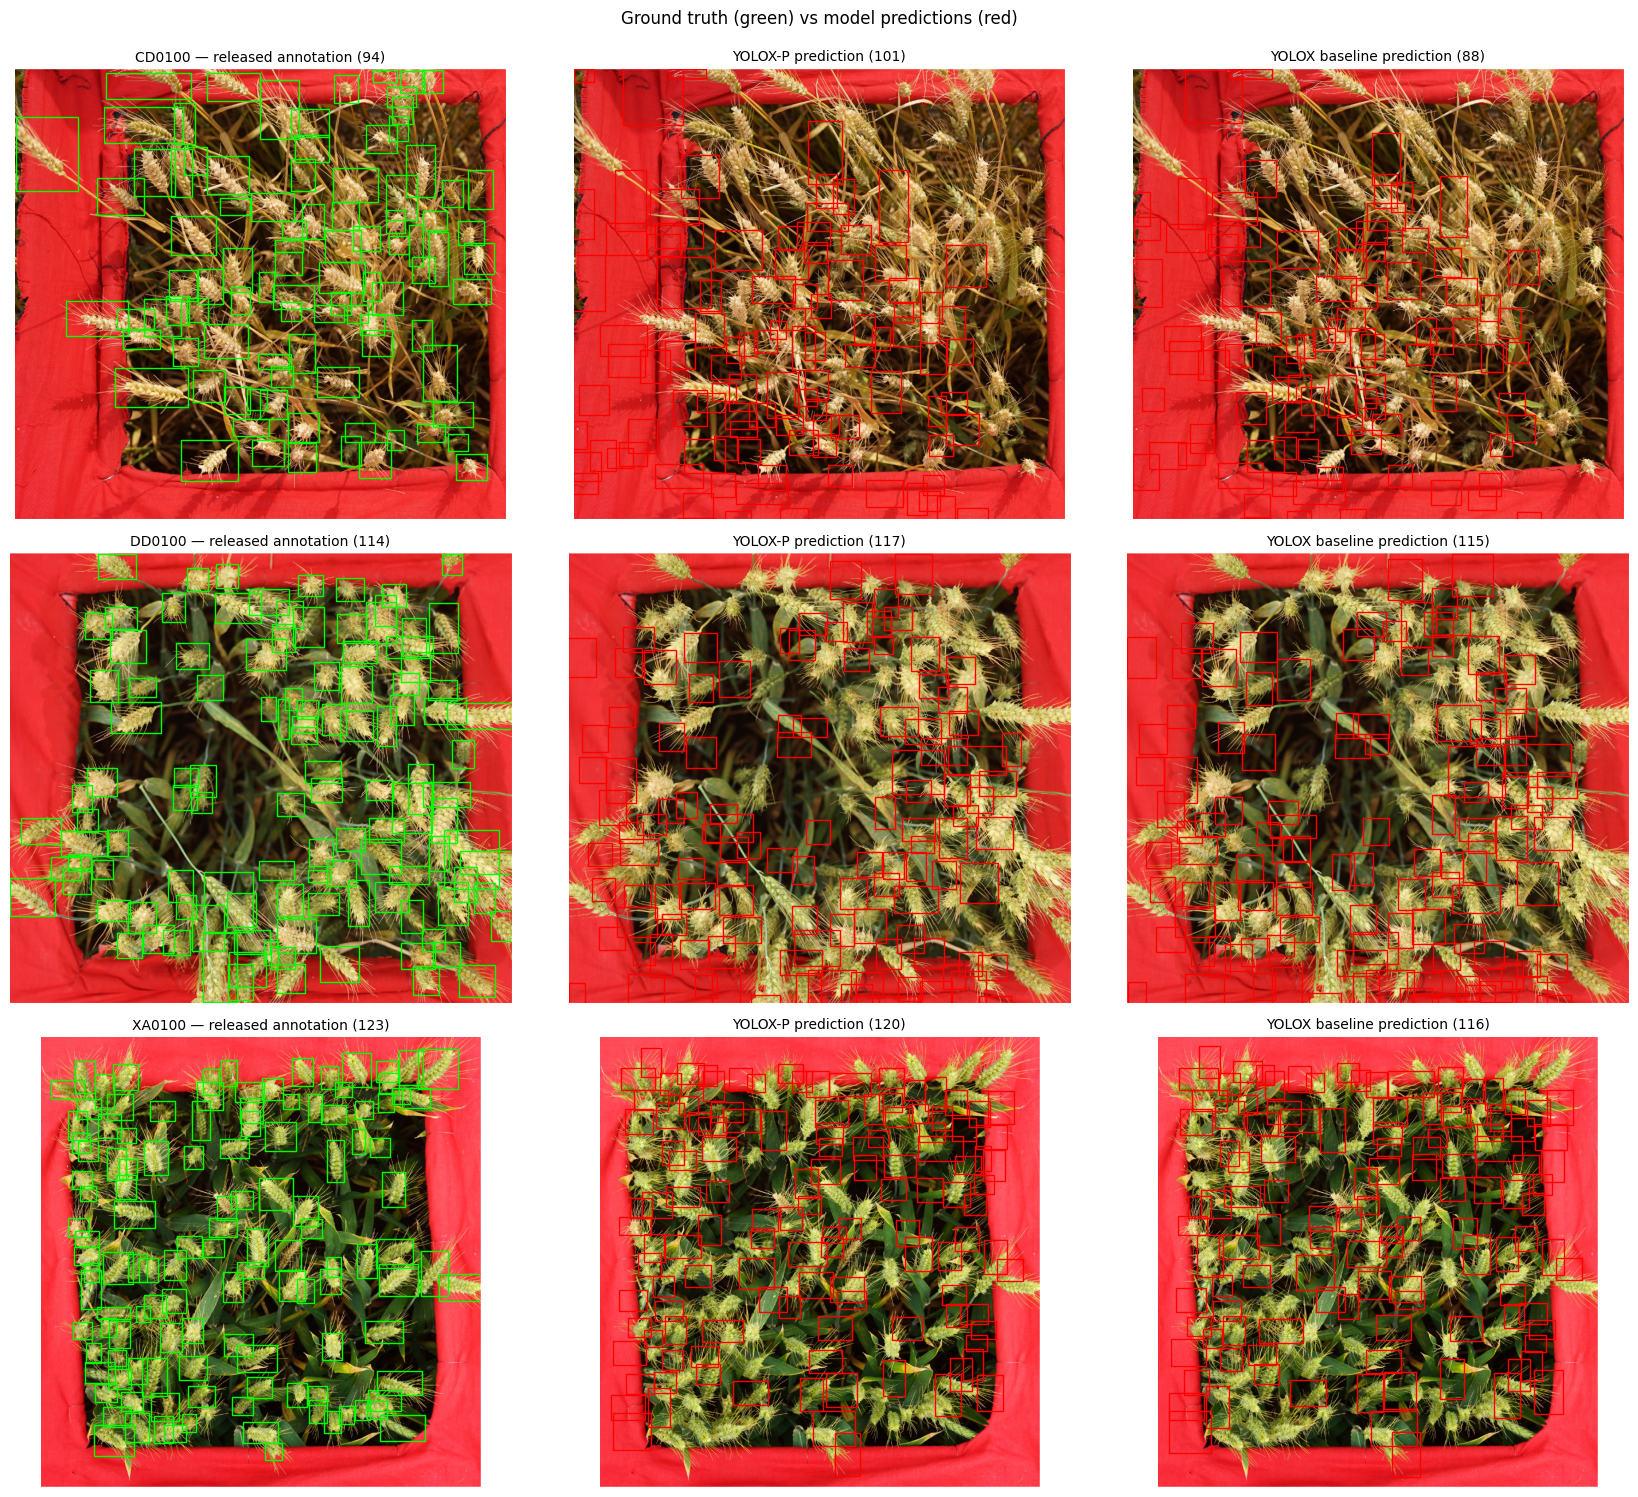

Saved /content/compare_predictions.png


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(17, 15))
for row, r in enumerate(results):
    image = Image.open(f"{DATA_DIR}/{r['sample']}.JPG").convert("RGB")
    panels = [
        (r["gt_boxes"], "lime", f"{r['sample']} — released annotation ({len(r['gt_boxes'])})"),
        (r["xp_boxes"].astype(int).tolist(), "red", f"YOLOX-P prediction ({len(r['xp_boxes'])})"),
        (r["x_boxes"].astype(int).tolist(), "red", f"YOLOX baseline prediction ({len(r['x_boxes'])})"),
    ]
    for col, (boxes, color, title) in enumerate(panels):
        ax = axes[row, col]
        ax.imshow(image)
        for (xmin, ymin, xmax, ymax) in boxes:
            ax.add_patch(patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                           linewidth=1.0, edgecolor=color, facecolor="none"))
        ax.set_title(title, fontsize=10)
        ax.axis("off")
fig.suptitle("Ground truth (green) vs model predictions (red)", y=0.995)
plt.tight_layout()
plt.savefig("/content/compare_predictions.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved /content/compare_predictions.png")

## 9. Results table and CSV export

A small per-sample summary: annotated spike count, predicted counts of both models, and absolute count errors. At single-image scale this only illustrates the task — the paper quantifies agreement over thousands of images (e.g., dataset-level mAP and count correlation), which is out of scope here.

**Expected result:** a compact table; the same content is written to `/content/spike_counts.csv`.

サンプルごとの結果表（正解数・両モデルの検出数・誤差）を表示し、CSV にも保存します。

In [ ]:
import pandas as pd

rows = []
for r in results:
    rows.append({
        "sample": r["sample"],
        "image_width_px": r["image_size"][0],
        "image_height_px": r["image_size"][1],
        "annotated_spikes": len(r["gt_boxes"]),
        "yoloxp_count": len(r["xp_boxes"]),
        "yolox_count": len(r["x_boxes"]),
        "yoloxp_abs_error": abs(len(r["xp_boxes"]) - len(r["gt_boxes"])),
        "yolox_abs_error": abs(len(r["x_boxes"]) - len(r["gt_boxes"])),
        "yoloxp_mean_conf": float(r["xp_scores"].mean()),
        "yolox_mean_conf": float(r["x_scores"].mean()),
        "yoloxp_time_s": round(r["xp_time_s"], 2),
        "yolox_time_s": round(r["x_time_s"], 2),
    })
df = pd.DataFrame(rows)
display(df)
df.to_csv("/content/spike_counts.csv", index=False)
print("Wrote /content/spike_counts.csv")

,sample,image_width_px,image_height_px,annotated_spikes,yoloxp_count,yolox_count,yoloxp_abs_error,yolox_abs_error,yoloxp_mean_conf,yolox_mean_conf,yoloxp_time_s,yolox_time_s
0,CD0100,2450,2247,94,101,88,7,6,0.641558,0.624568,4.14,1.74
1,DD0100,2504,2247,114,117,115,3,1,0.639424,0.617434,0.15,0.10
2,XA0100,1963,2010,123,120,116,3,7,0.648115,0.657398,0.14,0.09


Wrote /content/spike_counts.csv


## 10. Interpretation and limitations

* **What was reproduced:** the authors' released inference path — pinned code (`ba5e8f3`), released checkpoints (`YOLOXP.h5`, `YOLOX.h5`), their 960×960 / 640×640 letterbox preprocessing and decoding defaults — executed on three released samples from the paper's Drive-hosted CD&DD&XX set, with predicted spike counts compared against the released LabelImg annotations.
* **What this demonstrates:** that the released model + code detect and count wheat spikes in real canopy images, at single-image scale, on both CPU and GPU Colab runtimes.
* **What it does NOT demonstrate:** the paper's dataset-level metrics (e.g., the reported mAP of YOLOX-P vs YOLOX on CD&DD / CD&DD&XX, count-correlation with manual counts across environments) and anything about the QTL/KASP genetics subsection (no public genotype data — flagged in the paper's own investigation record). Three images cannot support any accuracy claim.
* **Assumptions recorded:** the YOLOX baseline is run at 640×640 (the paper raised the input to 960 only for YOLOX-P; the authors' forked YOLOX default is 640) and is built from the same pinned `yolo_body` with its CBAM blocks neutralized for that instantiation, because the released baseline checkpoint stores 157 layers (no CBAM) while the released `nets/` code contains only the CBAM-modified body — verified when the checkpoints were loaded. The released subset prefix `XA` is taken to be the paper's `XX` subset based on the released folder composition (594 CD / 610 DD / 716 XA). The paper text describes SPP pooling resized to 1/3/6/9 while the released code uses 5/9/13 max-pools — the released pinned code is authoritative for this reproduction.
* **License:** the author repository has no explicit license (empty LICENSE file). Use the code and weights only per the authors' terms.

* **再現したこと:** 著者公開コード（固定コミット）と公開チェックポイントをそのまま用い、公開サンプル 3 枚で穂検出・計数し、公開アノテーション数と比較した。
* **含まないこと:** データセット全体の mAP 評価、環境横断の計数一致評価、QTL/KASP 解析（公開遺伝データがないため）。3 枚の結果から精度の主張はできません。

## References

1. Paper: *RGB imaging and computer vision-based approaches for identifying spike number loci for wheat.* Plant Phenomics 7(2):100051 (2025). https://doi.org/10.1016/j.plaphe.2025.100051 (PMC12710032)
2. Author code: https://github.com/lileimax/YOLOXP-wheat-spike-identification @ `ba5e8f30699f3ec87c83b4ae30700925a0f391e8` (weights in `logs/`, accessed 2026-10-09)
3. Released dataset (VOC2007 format, CD&DD&XX subsets): Google Drive folder `1urCDUdyrq14FuwG2I3YwCZraUGEEl_8X` linked from the paper/repository
4. Base implementation the authors forked: bubbliiiing-style Keras YOLOX (`nets/`, `utils/` structure).